# Setup

In [56]:
import numpy as np
from sklearn.metrics import mean_squared_error as mse
from datetime import timedelta
import src.data.dataprep as prep
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# Start with the default (light) style
plt.style.use('default')

# Now update the rcParams to match your desired white-background style
plt.rcParams.update({
    'axes.facecolor': 'white',         # axes background
    'figure.facecolor': 'white',       # figure background
    'axes.edgecolor': 'black',         # border of plot
    'axes.labelcolor': 'black',        # axis labels
    'xtick.color': 'black',
    'ytick.color': 'black',
    'grid.color': 'black',             # grid lines color
    'grid.linewidth': 0.5,
    'grid.alpha': 0.2,                 # faint grid
    'font.size': 12,
    'legend.frameon': True,
    'lines.linewidth': 2,
    'figure.dpi': 180
})

DEFAULT_FONTS = {
    "title": 18,
    "subtitle": 16,      # subplot titles like "Winter"
    "xlabel": 14,
    "ylabel": 14,
    "xticks": 12,
    "yticks": 12,
    "legend": 12
}

def variable_df(dataframe, variable, model, datetime_component, norm=False, quantiles=[0.1, 0.25, 0.5, 0.75, 0.9]):
    # Step 1: Round and convert

    if variable == 'cost' and datetime_component == 'month':
        dataframe = dataframe.resample('D').sum()

    df_rounded = dataframe.round(4).astype('float32')

    # Step 2: Slice by variable
    df_var = df_rounded.xs(variable, level='variable', axis=1)

    # Step 3: Normalize if needed
    if norm:
        df_var = df_var / (df_var.iloc[0] * 2)

    # Step 4: Slice by model
    df_model = df_var.xs(model, level='dictionary', axis=1)

    # Step 5: Create datetime component column (e.g., hour)
    df_model = df_model.copy()
    df_model[datetime_component] = getattr(df_model.index, datetime_component)

    # Step 6: Melt to long format (one value per row)
    df_melted = df_model.melt(id_vars=datetime_component, var_name='building', value_name='value')

    # Step 7: Group by datetime component (e.g., hour) and compute quantiles across buildings
    df_quantiles = df_melted.groupby(datetime_component)['value'].quantile(quantiles).unstack()
    df_quantiles.columns = [f'Q{int(q*100):02d}' for q in quantiles]

    return df_quantiles

def plot_scatter_plot(mse_data, cost_data):
    # Create a figure
    plt.figure(figsize=(8, 5), dpi=180)

    # Scatter plot for each model
    for model in mse_data.keys():
        # Get the MSE and cost values for each building
        mse_values = mse_data[model]
        cost_values = cost_data[model]

        # Scatter plot
        plt.scatter(mse_values, cost_values, label=model, alpha=0.7)

    # Set labels and title
    plt.xlabel("RMSE", fontsize=12)
    plt.ylabel("Cost", fontsize=12)
    plt.title("Scatter Plot of Cost vs. RMSE", fontsize=18, fontweight="bold")

    # Add a legend
    plt.legend(title="Models", loc="lower left", fontsize=14)

    # Show grid for better visibility
    plt.grid(True, linestyle="--", alpha=0.6)

    # Set limits
    plt.xlim(0.3,1.05)
    plt.ylim(0.6,1.05)

    # Show the plot
    plt.tight_layout()
    plt.show()

def hourly_quantile_plot(stats, size=(14, 6), title='Hourly Distribution Across Buildings and Days'):
    plt.figure(figsize=size)

    # Plot median
    plt.plot(stats.index, stats['Q50'], label='Median (Q50)', color='blue')

    # Fill interquartile range (Q25–Q75)
    if 'Q25' in stats.columns and 'Q75' in stats.columns:
        plt.fill_between(
            stats.index,
            stats['Q25'],
            stats['Q75'],
            color='blue',
            alpha=0.25,
            label='Interquartile Range (Q25–Q75)'
        )

    # Fill outer range (Q10–Q90)
    if 'Q10' in stats.columns and 'Q90' in stats.columns:
        plt.fill_between(
            stats.index,
            stats['Q10'],
            stats['Q90'],
            color='blue',
            alpha=0.15,
            label='10th–90th Percentile Range'
        )

    plt.xticks(range(len(stats)))
    plt.xlabel('Hour of Day')
    plt.ylabel('Value')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def compare_hourly_quantile_plots(stats_list, rowtitles, columns=3, rows=1, titles=None, x_axis='Hour of the day', size=(18, 5), fonts=DEFAULT_FONTS):
    n = len(stats_list)
    if titles is None:
        titles = [f"Plot {i+1}" for i in range(n)]

    # Step 1: Find global min and max across all stats
    global_min = min(df[[col for col in df.columns if col.startswith('Q')]].min().min() for df in stats_list)
    global_max = max(df[[col for col in df.columns if col.startswith('Q')]].max().max() for df in stats_list)

    # Step 2: Create subplots (note: rows first!)
    fig, axes = plt.subplots(rows, columns, figsize=size, sharey=True, dpi=180)

    # Flatten axes for easy iteration
    axes = axes.flatten() if isinstance(axes, (list, np.ndarray)) else [axes]

    for row in range(rows):
            # Compute y position (between 0 and 1, from bottom to top)
            y_pos = 1 - (row + 0.7) / rows
            fig.text(
                0,
                y_pos,
                rowtitles[row],
                ha='center',
                va='center',
                rotation=90,
                fontsize=fonts["subtitle"],
                fontweight='bold'
            )
    # Step 3: Plot each
    for i, (ax, stats, title) in enumerate(zip(axes, stats_list, titles)):
        line_color = '#66B2FF'
        fill_iqr_color = '#66B2FF'
        fill_outer_color = '#66B2FF'

        ax.plot(stats.index, stats['Q50'], label='Median (Q50)', color=line_color)

        if 'Q25' in stats.columns and 'Q75' in stats.columns:
            ax.fill_between(
                stats.index, stats['Q25'], stats['Q75'],
                color=fill_iqr_color, alpha=0.4,
                label='IQR (Q25–Q75)' if i == 0 else None
            )

        if 'Q10' in stats.columns and 'Q90' in stats.columns:
            ax.fill_between(
                stats.index, stats['Q10'], stats['Q90'],
                color=fill_outer_color, alpha=0.2,
                label='P10–P90' if i == 0 else None
            )

        ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)

        ax.set_title(title, fontsize=fonts["subtitle"])
        ax.set_xlabel(x_axis, fontsize=fonts["xlabel"])
        ax.set_ylabel("kWh", fontsize=fonts["ylabel"])
        ax.grid(True)
        ax.set_xticks(range(0, len(stats), 2))
        ax.tick_params(axis='x', labelsize=fonts["xticks"])
        ax.tick_params(axis='y', labelsize=fonts["yticks"])
        ax.set_ylim(global_min, global_max * 1.1)


    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0), ncol=3, fontsize=fonts["legend"])

    fig.suptitle('Averaged hourly PV forecasts per model', fontsize=fonts['title'], fontweight='bold')
    plt.tight_layout()
    plt.show()

def hourly_combo_confidence_plot(stats1, stats2, label1='Dataset 1', label2='Dataset 2', color1='blue', color2='green'):

    # Plotting
    plt.figure(figsize=(14, 6))

    # Plot mean lines
    plt.plot(stats1.index, stats1['mean'], label=f'{label1} Mean', color=color1)
    plt.plot(stats2.index, stats2['mean'], label=f'{label2} Mean', color=color2)

    # Plot confidence intervals
    for i, alpha in zip([1, 2], [0.3, 0.15]):
        plt.fill_between(
            stats1.index,
            stats1['mean'] - i * stats1['std'],
            stats1['mean'] + i * stats1['std'],
            color=color1,
            alpha=alpha,
            label=f'{label1} ±{i} Std Dev' if i == 1 else None  # Avoid repeating in legend
        )
        plt.fill_between(
            stats2.index,
            stats2['mean'] - i * stats2['std'],
            stats2['mean'] + i * stats2['std'],
            color=color2,
            alpha=alpha,
            label=f'{label2} ±{i} Std Dev' if i == 1 else None
        )

    plt.xticks(range(len(stats1)))
    plt.ylim(min(min(stats1['mean'] - 3 * stats1['std']),min(stats2['mean'] - 3 * stats2['std'])), max(max(stats1['mean'] + 3 * stats1['std']),max(stats2['mean'] + 3 * stats2['std'])))
    plt.xlabel('Hour of Day')
    plt.ylabel('Value')
    plt.title('Hourly Average with Confidence Intervals for Two Datasets')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [2]:
noise = 0.5

In [3]:
import pandas as pd
import pickle
import glob
import os

# -----------------------------
# 1️⃣ Create the datetime index
# -----------------------------
start_time = '2020-05-08 00:00:00'
end_time = '2021-07-31 23:00:00'
datetime_index = pd.date_range(start=start_time, end=end_time, freq='H')
n_timesteps = len(datetime_index)
print(f"Number of timesteps: {n_timesteps}")

# -----------------------------
# 2️⃣ Find all pickle files
# -----------------------------
path_pattern = "../results/optimisation/single_opt_building_*_0.5_noise.pkl"
pickle_files = sorted(glob.glob(path_pattern))
print(f"Found {len(pickle_files)} pickle files.")

# -----------------------------
# 3️⃣ Read pickles and create df_long
# -----------------------------
records = []
for pf in pickle_files:
    # Extract building name
    basename = os.path.basename(pf)
    building_number = basename.split('_')[3]
    building_name = f"building_{building_number}"
    
    # Load pickle
    with open(pf, 'rb') as f:
        data = pickle.load(f)  # dict of dicts: model -> variable -> array
    
    # Compute cost per model before flattening
    for model, variables_dict in data.items():
        # Calculate piecewise cost: off_take * exp - imp * injection
        off = variables_dict['offtake']      # shape (450,24)
        imp = variables_dict['imp']
        inj = variables_dict['injection']
        exp = variables_dict['exp']

        # Cost array same shape as other variables
        cost_array = off * imp - inj * exp
        variables_dict['cost'] = cost_array  # add new variable
    
        # Now process all variables for flattening
        for var, array in variables_dict.items():
            # Fix 'energy'
            if var == 'energy' and array.shape[1] == 25:
                array = array[:, :-1]  # drop last column
            
            array = array.flatten()
            
            if len(array) != n_timesteps:
                raise ValueError(f"Array length for {building_name}, {model}, {var} ({len(array)}) "
                                 f"does not match datetime index ({n_timesteps})")
            
            # Append to records
            for t, value in enumerate(array):
                records.append({
                    'datetime': datetime_index[t],
                    'building': building_name,
                    'dictionary': model,
                    'variable': var,
                    'value': value
                })


C:\Users\jdepoort\AppData\Local\Temp\ipykernel_3540\188195059.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  datetime_index = pd.date_range(start=start_time, end=end_time, freq='H')


Number of timesteps: 10800
Found 20 pickle files.


In [4]:
# -----------------------------
# 4️⃣ Create the long-form dataframe
# -----------------------------
df_long = pd.DataFrame(records)
df_long = df_long.set_index('datetime')

In [5]:
# Pivot to have variables as columns
df = df_long.pivot_table(index='datetime', 
                              columns=['variable', 'building', 'dictionary'], 
                              values='value')

In [6]:
example_building = 'building_9'

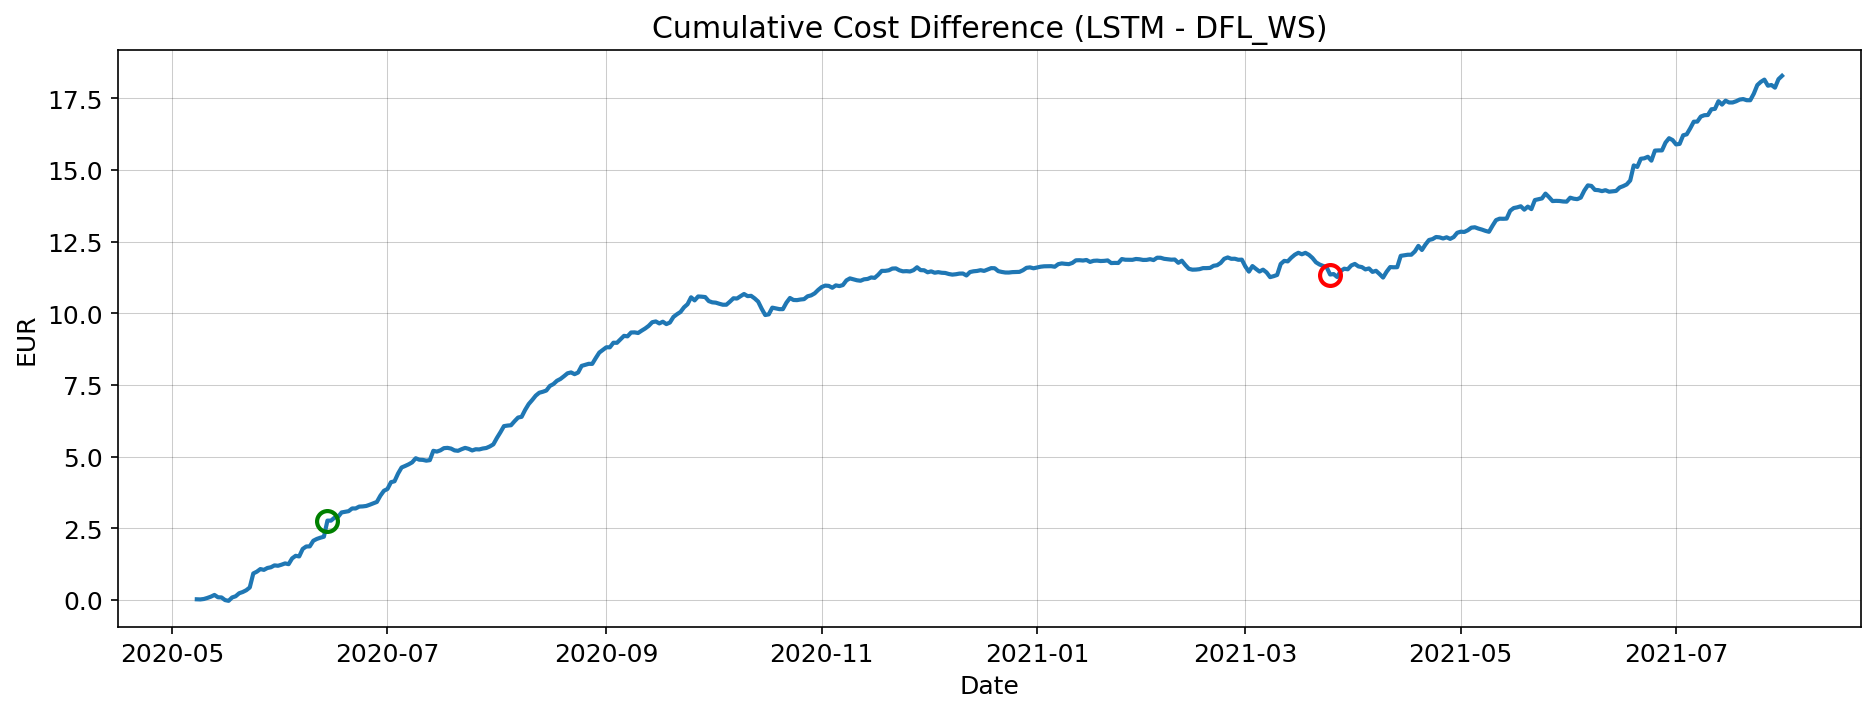

The day where LSTM cost was **highest relative to LSTM_CVX** (max positive difference):
  Date: 2020-06-14, Difference: 0.562 (LSTM > LSTM_CVX)
--------------------------------------------------
The day where LSTM cost was **lowest relative to LSTM_CVX** (max negative difference):
  Date: 2021-03-25, Difference: -0.257 (LSTM_CVX > LSTM)


In [7]:
df_long_lstm = df_long[(df_long['building'] == example_building) & (df_long['dictionary'] == 'lstm') & (df_long['variable'] == 'cost')]
df_long_lstm_cvx = df_long[(df_long['building'] == example_building) & (df_long['dictionary'] == 'lstm_cvx') & (df_long['variable'] == 'cost')]

# Calculate daily sums
daily_cost_lstm = df_long_lstm['value'].resample('D').sum()
daily_cost_lstm_cvx = df_long_lstm_cvx['value'].resample('D').sum()

# Calculate the signed difference: Daily Cost LSTM - Daily Cost LSTM_CVX
daily_signed_diff = daily_cost_lstm - daily_cost_lstm_cvx

# --- Find the Maximum Positive and Negative Difference Days ---
max_pos_diff_day = daily_signed_diff.idxmax()
max_pos_diff_value = daily_signed_diff.max()
max_neg_diff_day = daily_signed_diff.idxmin()
max_neg_diff_value = daily_signed_diff.min()

# --- Calculate Cumulative Difference and Identify Marker Coordinates ---
cumulative_diff = daily_cost_lstm.cumsum() - daily_cost_lstm_cvx.cumsum()

# Coordinates for the Maximum Positive Day
pos_marker_x = max_pos_diff_day
pos_marker_y = cumulative_diff.loc[max_pos_diff_day]

# Coordinates for the Maximum Negative Day
neg_marker_x = max_neg_diff_day
neg_marker_y = cumulative_diff.loc[max_neg_diff_day]


# --- Plotting ---
plt.figure(figsize=(15,5))

# 1. Plot the main cumulative difference line
plt.plot(cumulative_diff, label="Cumulative Difference (LSTM - DFL_WS)")

# 2. Add the Green Outline Dot (Max Positive Daily Difference)
plt.plot(pos_marker_x, pos_marker_y,
         marker='o',
         markersize=10, # Increased size slightly for better visibility as an outline
         color='green',
         fillstyle='none', # KEY CHANGE: No fill inside the marker
         linestyle='none', # Ensure no line segment connects the marker
         markeredgewidth=2, # Make the outline thicker
         label=f"Max Positive Daily Diff ({max_pos_diff_day.date()})")

# 3. Add the Red Outline Dot (Max Negative Daily Difference)
plt.plot(neg_marker_x, neg_marker_y,
         marker='o',
         markersize=10, # Increased size slightly for better visibility as an outline
         color='red',
         fillstyle='none', # KEY CHANGE: No fill inside the marker
         linestyle='none', # Ensure no line segment connects the marker
         markeredgewidth=2, # Make the outline thicker
         label=f"Max Negative Daily Diff ({max_neg_diff_day.date()})")

# --- Formatting ---
plt.title("Cumulative Cost Difference (LSTM - DFL_WS)")
plt.xlabel("Date")
plt.ylabel("EUR")
plt.grid(True)
plt.show()

# --- Print Results (unchanged) ---
print(f"The day where LSTM cost was **highest relative to LSTM_CVX** (max positive difference):")
print(f"  Date: {max_pos_diff_day.date()}, Difference: {max_pos_diff_value:.3f} (LSTM > LSTM_CVX)")
print("-" * 50)
print(f"The day where LSTM cost was **lowest relative to LSTM_CVX** (max negative difference):")
print(f"  Date: {max_neg_diff_day.date()}, Difference: {max_neg_diff_value:.3f} (LSTM_CVX > LSTM)")

In [8]:
worst_or_best = 'worst'
if worst_or_best == 'best':
    start = max_pos_diff_day.strftime('%Y-%m-%d %H:%M:%S')
    end   = (max_pos_diff_day + timedelta(days=1)).strftime('%Y-%m-%d %H:%M:%S')
else:
    start = max_neg_diff_day.strftime('%Y-%m-%d %H:%M:%S')
    end   = (max_neg_diff_day + timedelta(days=1)).strftime('%Y-%m-%d %H:%M:%S')

In [9]:
# --- Inputs ---
vars = ["exp", "imp", "charge", "discharge", "load","pv", 'energy','cost']   # example variables
building = example_building

# --- Helper function to filter + pivot ---
def get_wide(df, dictionary):
    df_plot = df[
        (df['building'] == building) &
        (df['dictionary'] == dictionary) &
        (df.index >= start) &
        (df.index <= end) &
        (df['variable'].isin(vars))
    ]
    return df_plot.pivot_table(index="datetime", columns="variable", values="value")

# Get wide-format data for both dictionaries
df_lstm     = get_wide(df_long, "lstm")
df_lstm_cvx = get_wide(df_long, "lstm_cvx")

df_lstm['cost'] = df_lstm['cost'].cumsum()
df_lstm_cvx['cost'] = df_lstm_cvx['cost'].cumsum()

df_lstm['net import'] = df_lstm['imp'] - df_lstm['exp']
df_lstm['charging & discharging'] = df_lstm['discharge'] - df_lstm['charge']

df_lstm_cvx['net import'] = df_lstm_cvx['imp'] - df_lstm_cvx['exp']
df_lstm_cvx['charging & discharging'] = df_lstm_cvx['discharge'] - df_lstm_cvx['charge']

nl_data = prep.dutch_data('../data/Dutchdata_clean/building_0.parquet', 'h', price="Realistic")
df_lstm['real PV'] = nl_data[start:end]['solar_energy']

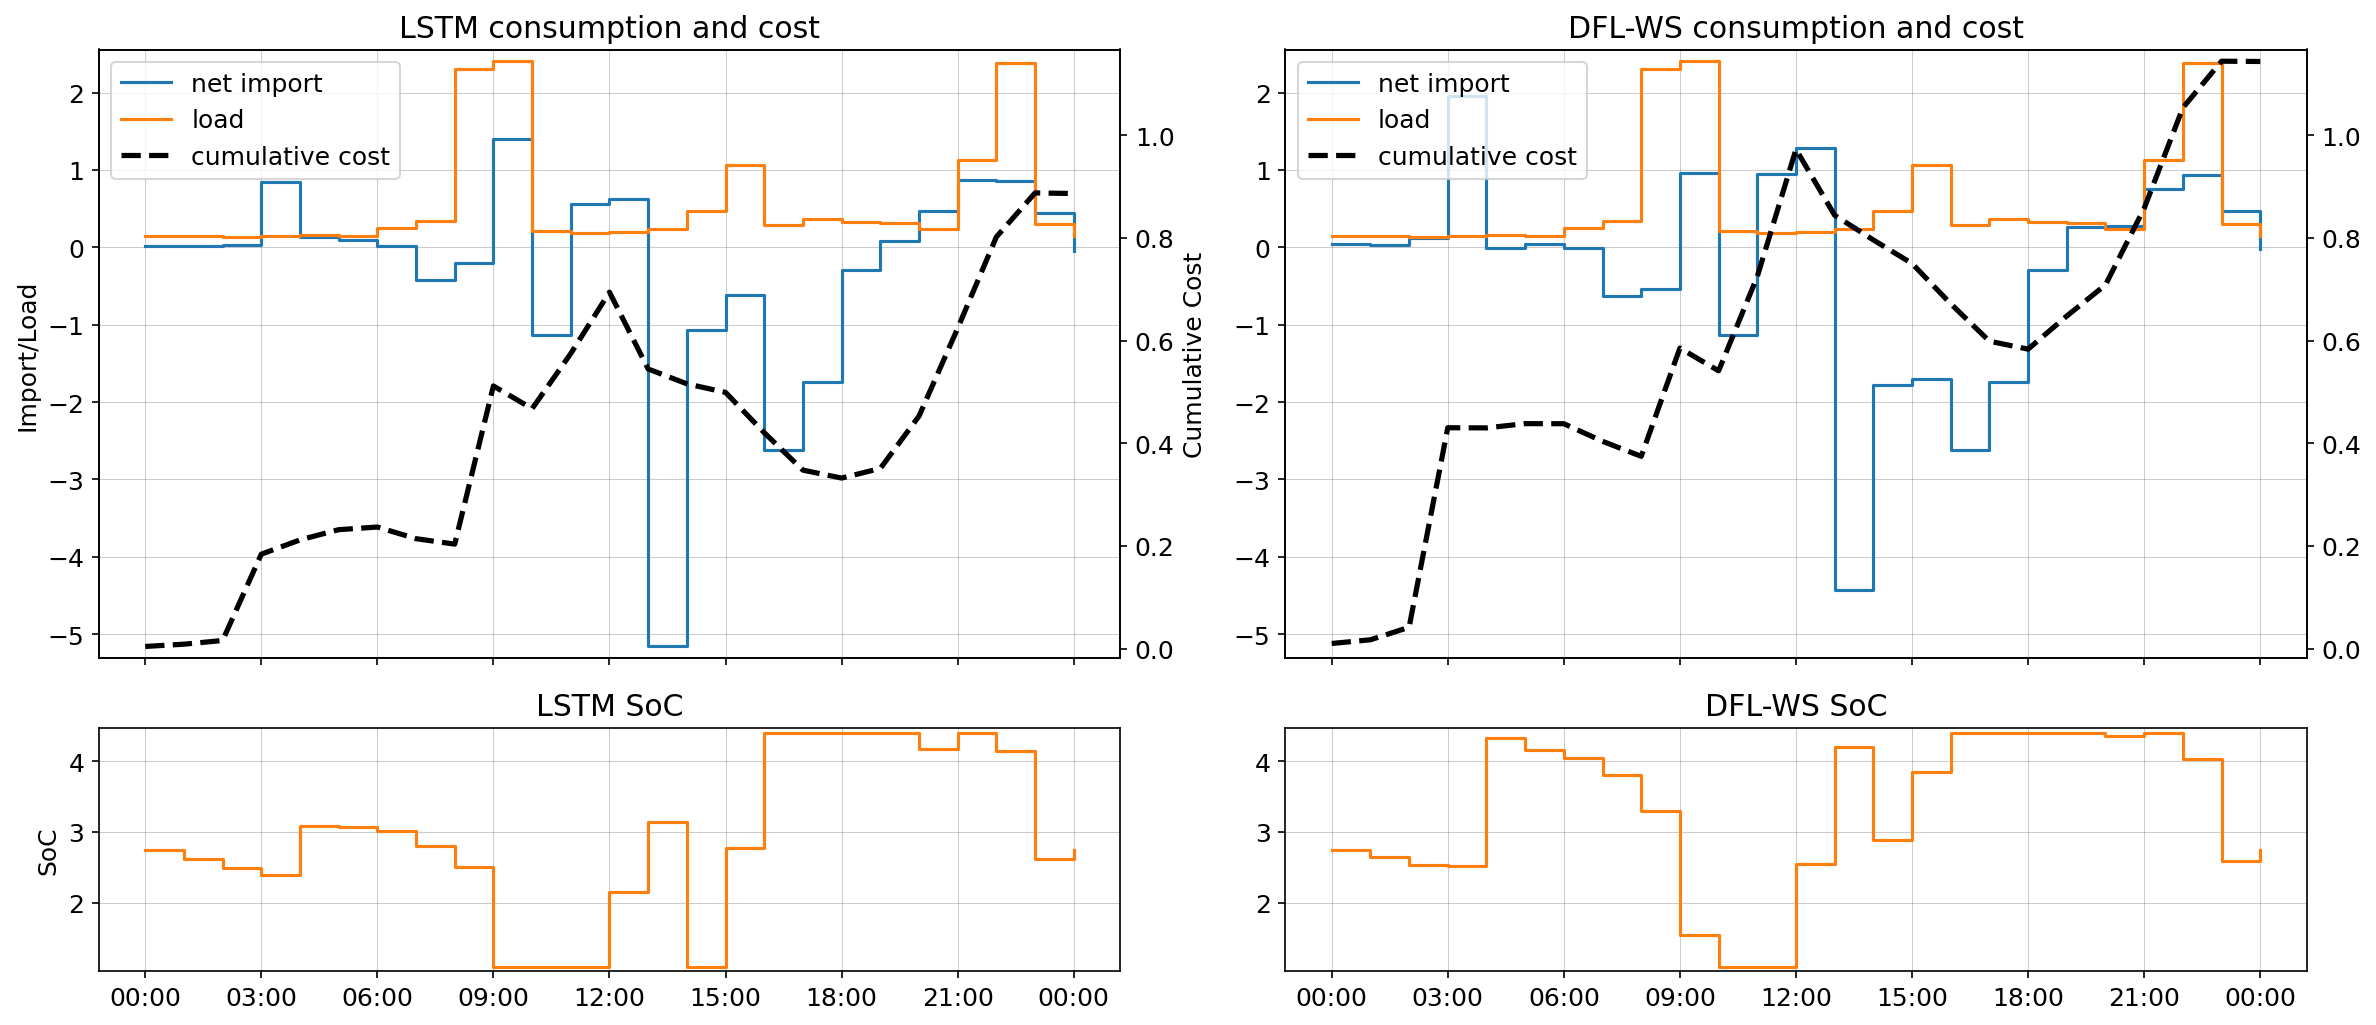

The LSTM cumulative cost is 0.886
The DFL model cumulative cost is 1.144


In [10]:
vars_to_plot = ['net import', 'load', 'energy', 'cost']

# Define the padding percentage
PADDING_PERCENT = 0.02 # 2% buffer

# Identify variables plotted on the primary (main) axis (excluding cost and energy)
main_vars = [v for v in vars_to_plot if v not in ["cost", "energy"]]

# Initialize lists to store min/max values found across both dataframes
min_vals_main = []
max_vals_main = []
min_vals_cost = []
max_vals_cost = []
min_vals_energy = [] # Added for bottom plot limits
max_vals_energy = [] # Added for bottom plot limits


# --- Calculate Main Axis Limits (unbuffered) ---
# Collect min/max from df_lstm main variables
if all(v in df_lstm.columns for v in main_vars) and main_vars:
    min_vals_main.append(df_lstm[main_vars].min().min())
    max_vals_main.append(df_lstm[main_vars].max().max())

# Collect min/max from df_lstm_cvx main variables
if all(v in df_lstm_cvx.columns for v in main_vars) and main_vars:
    min_vals_main.append(df_lstm_cvx[main_vars].min().min())
    max_vals_main.append(df_lstm_cvx[main_vars].max().max())

# Determine the final global limits for the main axis
if min_vals_main:
    raw_main_min = min(min_vals_main)
    raw_main_max = max(max_vals_main)

    # Apply 2% buffer 📈
    range_main = raw_main_max - raw_main_min
    buffer_main = range_main * PADDING_PERCENT

    global_main_min = raw_main_min - buffer_main
    global_main_max = raw_main_max + buffer_main
else:
    # Fallback to buffered manual limits if no variables found
    global_main_min, global_main_max = -5.1, 5.1


# --- Calculate Secondary (Cost) Axis Limits (unbuffered) ---
if "cost" in df_lstm.columns:
    min_vals_cost.append(df_lstm["cost"].min())
    max_vals_cost.append(df_lstm["cost"].max())

if "cost" in df_lstm_cvx.columns:
    min_vals_cost.append(df_lstm_cvx["cost"].min())
    max_vals_cost.append(df_lstm_cvx["cost"].max())

# Determine the final global limits for the cost axis
if min_vals_cost:
    raw_cost_min = min(min_vals_cost)
    raw_cost_max = max(max_vals_cost)

    # Apply 2% buffer 💰
    range_cost = raw_cost_max - raw_cost_min
    buffer_cost = range_cost * PADDING_PERCENT

    global_cost_min = raw_cost_min - buffer_cost
    global_cost_max = raw_cost_max + buffer_cost
else:
    # Fallback to buffered manual limits if cost is not found
    global_cost_min, global_cost_max = -1.02, 0.51

# --- Calculate Energy (SoC) Axis Limits (unbuffered) ---
if "energy" in df_lstm.columns:
    min_vals_energy.append(df_lstm["energy"].min())
    max_vals_energy.append(df_lstm["energy"].max())

if "energy" in df_lstm_cvx.columns:
    min_vals_energy.append(df_lstm_cvx["energy"].min())
    max_vals_energy.append(df_lstm_cvx["energy"].max())

# Determine the final global limits for the energy axis (This ensures both bottom plots have same scale)
if min_vals_energy:
    raw_energy_min = min(min_vals_energy)
    raw_energy_max = max(max_vals_energy)

    # Apply 2% buffer
    range_energy = raw_energy_max - raw_energy_min
    buffer_energy = range_energy * PADDING_PERCENT

    global_energy_min = raw_energy_min - buffer_energy
    global_energy_max = raw_energy_max + buffer_energy
else:
    # Fallback
    global_energy_min, global_energy_max = 0.9, 4.1 # Based on image scale of 1-4


# --- 2. PLOTTING CODE (Dynamic limits and **STEP PLOTS** applied) ---

# Use the 'dark_background' style if you want to keep the look from the image
# plt.style.use('dark_background')

fig, axes = plt.subplots(2, 2, figsize=(16, 7), sharex=True,
                         gridspec_kw={'height_ratios': [5, 2]})

# Line widths
main_lw = 1.5
cost_lw = 2.5

# Apply date formatter to the bottom row axes only
for ax in axes[1, :]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# --- Top-Left plot: LSTM (Variables and Cost) ---
ax_top_left = axes[0, 0]
ax_top_left2 = ax_top_left.twinx()
for v in vars_to_plot:
    if v in df_lstm and v not in ["cost", "energy"]:
        # Apply step plot to net import and load
        ax_top_left.plot(df_lstm.index, df_lstm[v],
                         label=v,
                         lw=main_lw,
                         drawstyle='steps-post') # <-- STEP PLOT
    elif v == "cost" and v in df_lstm:
        # Cumulative cost usually looks better with a regular line, or step-post
        # if the cost is calculated at the end of the interval. Sticking to regular line for now.
        # Use zorder=5 to ensure the cumulative_cost line is clearly visible
        ax_top_left2.plot(df_lstm.index, df_lstm["cost"],
                          label="cumulative cost",
                          color="black",
                          lw=cost_lw,
                          ls='--',
                          zorder=5) # <-- LINE PLOT

ax_top_left.set_title("LSTM consumption and cost")
ax_top_left.grid(True)
ax_top_left.set_ylabel("Import/Load") # Clarify Y-axis
ax_top_left2.set_ylabel("Cumulative Cost") # Clarify Secondary Y-axis

# APPLY BUFFERED DYNAMIC LIMITS
ax_top_left.set_ylim(global_main_min, global_main_max)
ax_top_left2.set_ylim(global_cost_min, global_cost_max)

# Combine legends
lines, labels = ax_top_left.get_legend_handles_labels()
lines2, labels2 = ax_top_left2.get_legend_handles_labels()
ax_top_left.legend(lines + lines2, labels + labels2, loc="upper left")

# --- Top-Right plot: LSTM_CVX (Variables and Cost) ---
ax_top_right = axes[0, 1]
ax_top_right2 = ax_top_right.twinx()
for v in vars_to_plot:
    if v in df_lstm_cvx and v not in ["cost", "energy"]:
        # Apply step plot to net import and load
        ax_top_right.plot(df_lstm_cvx.index, df_lstm_cvx[v],
                          label=v,
                          lw=main_lw,
                          drawstyle='steps-post') # <-- STEP PLOT
    elif v == "cost" and v in df_lstm_cvx:
        # Use zorder=5 to ensure the cumulative_cost line is clearly visible
        ax_top_right2.plot(df_lstm_cvx.index, df_lstm_cvx["cost"],
                           label="cumulative cost",
                           color="black",
                           lw=cost_lw,
                           ls='--',
                           zorder=5) # <-- LINE PLOT

ax_top_right.set_title("DFL-WS consumption and cost")
ax_top_right.grid(True)

# APPLY BUFFERED DYNAMIC LIMITS
ax_top_right.set_ylim(global_main_min, global_main_max)
ax_top_right2.set_ylim(global_cost_min, global_cost_max)

# Combine legends
lines, labels = ax_top_right.get_legend_handles_labels()
lines2, labels2 = ax_top_right2.get_legend_handles_labels()
ax_top_right.legend(lines + lines2, labels + labels2, loc="upper left")

# --- Bottom-Left plot: LSTM Energy (SoC) ---
ax_bottom_left = axes[1, 0]
if "energy" in df_lstm:
    # Apply step plot to energy/SoC
    ax_bottom_left.plot(df_lstm.index, df_lstm["energy"],
                        color="tab:orange",
                        lw=main_lw,
                        drawstyle='steps-post') # <-- STEP PLOT
ax_bottom_left.set_title("LSTM SoC")
ax_bottom_left.set_ylabel("SoC") # Clarify Y-axis
ax_bottom_left.grid(True)
ax_bottom_left.set_ylim(global_energy_min, global_energy_max) # APPLY GLOBAL LIMITS

# --- Bottom-Right plot: LSTM_CVX Energy (SoC) ---
ax_bottom_right = axes[1, 1]
if "energy" in df_lstm_cvx:
    # Apply step plot to energy/SoC
    ax_bottom_right.plot(df_lstm_cvx.index, df_lstm_cvx["energy"],
                         color="tab:orange",
                         lw=main_lw,
                         drawstyle='steps-post') # <-- STEP PLOT
ax_bottom_right.set_title("DFL-WS SoC")
ax_bottom_right.grid(True)
ax_bottom_right.set_ylim(global_energy_min, global_energy_max) # APPLY GLOBAL LIMITS

plt.tight_layout()
plt.show()

print(f"The LSTM cumulative cost is {df_lstm['cost'].iloc[-1]:.3f}")
print(f"The DFL model cumulative cost is {df_lstm_cvx['cost'].iloc[-1]:.3f}")

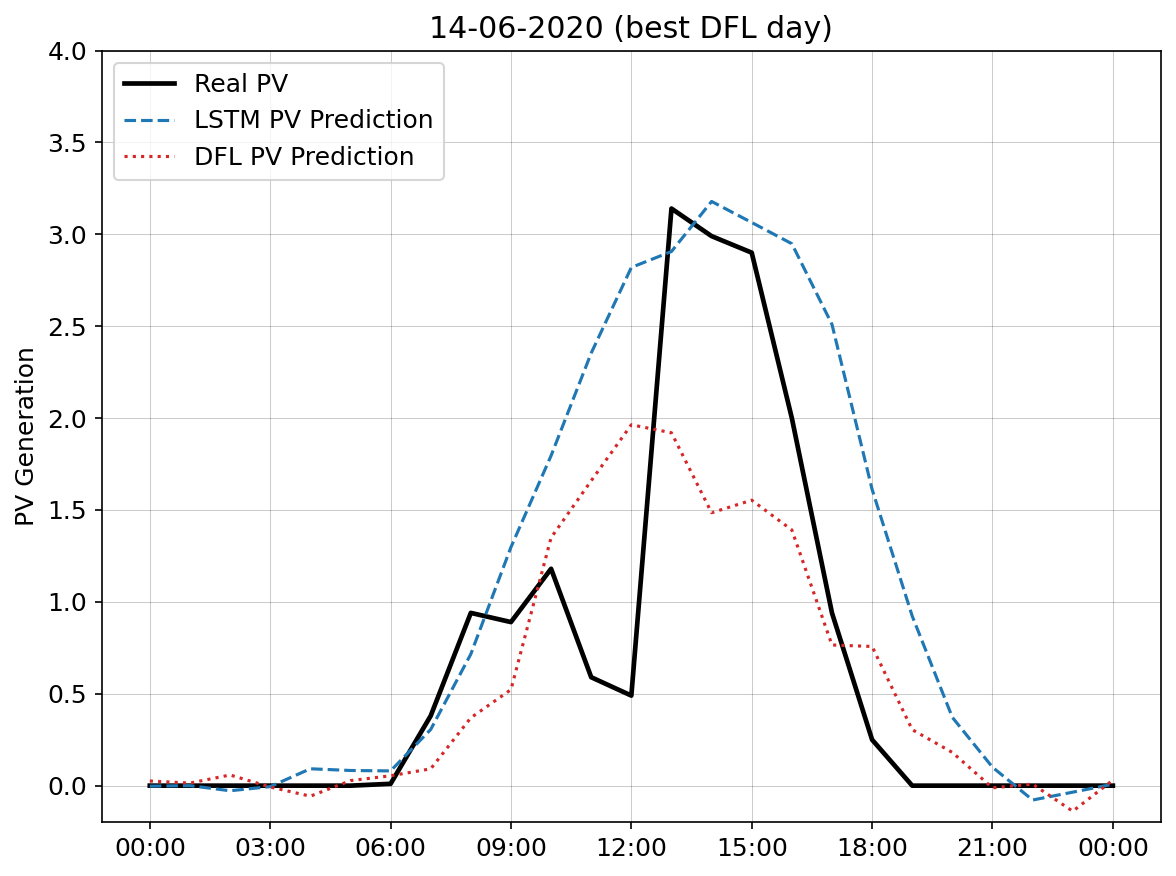

In [11]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# Set up the figure and a single axis
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Apply the date formatter for time display
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Line width consistency (redefining the variable for a standalone script)
main_lw = 1.5

# --- Plot the variables ---

# 1. Plot the actual/real PV generation (usually a different style/color to distinguish it)
ax.plot(df_lstm.index, df_lstm['real PV'],
        label='Real PV',
        color='black', # Use a bold color for the real data
        lw=main_lw * 1.5, # Slightly thicker line for emphasis
        ls='-') # Solid line

# 2. Plot the LSTM predicted PV
ax.plot(df_lstm.index, df_lstm['pv'],
        label='LSTM PV Prediction',
        color='tab:blue',
        lw=main_lw,
        ls='--') # Dashed line to distinguish from real PV

# 3. Plot the LSTM_CVX predicted PV
ax.plot(df_lstm_cvx.index, df_lstm_cvx['pv'],
        label='DFL PV Prediction',
        color='tab:red',
        lw=main_lw,
        ls=':') # Dotted line to distinguish from other prediction

# --- Formatting ---
ax.set_title("14-06-2020 (best DFL day)")
ax.set_ylabel("PV Generation")
ax.set_ylim(-0.2,4)
ax.grid(True)
ax.legend(loc="upper left")

plt.tight_layout()

In [12]:
buildings = list(df_long.building.unique())
models = list(df_long.dictionary.unique())

In [13]:
model_mse = {model: [] for model in models}
model_costs = {model: [] for model in models}

df_pv = df_long[df_long['variable'] == 'pv']
df_cost = df_long[df_long['variable'] == 'cost']

for model in models:
    for building in buildings:
        true_vals = df_pv[(df_pv['building'] == building) & (df_pv['dictionary'] == 'perfect')].value
        pred_vals = df_pv[(df_pv['building'] == building) & (df_pv['dictionary'] == model)].value
        
        rmse = np.sqrt(mse(true_vals / max(true_vals), pred_vals / max(true_vals)))
        model_mse[model].append(rmse)

        model_costs[model].append(sum(df_cost[(df_cost['building'] == building) & (df_cost['dictionary'] == model)].value)) # profit for injection

In [14]:
no_opt_costs = []

df_load = df_long[df_long['variable'] == 'load']
df_off = df_long[df_long['variable'] == 'offtake']
df_in = df_long[df_long['variable'] == 'injection']

for building in buildings:
    # Calculate net energy: positive = surplus, negative = deficit
    net_energy = np.array((df_pv[(df_pv['building'] == building) & (df_pv['dictionary'] == 'perfect')].value -
                             df_load[(df_load['building'] == building) & (df_load['dictionary'] == 'perfect')].value))
    no_opt_costs.append(
        sum(
            np.where(
                     net_energy < 0,
                     -net_energy * np.array(df_off[(df_off['building'] == building) & (df_off['dictionary'] == 'perfect')].value),      # Buying energy: cost
                     -net_energy * np.array(df_in[(df_in['building'] == building) & (df_in['dictionary'] == 'perfect')].value)    # Selling energy: revenue (negative cost)
        )))

In [15]:
for key in model_mse.keys():
    print(np.average(model_mse[key]))

0.0
0.13790586564785184
0.08228927636033215
0.19900651496682537
0.13699263841798878


In [16]:
for key in model_mse.keys():
    print(key + ': ' + str(np.average(model_costs[key])))
print('no opt: ' + str(np.average(no_opt_costs)))

perfect: 281.3504441331464
naive: 393.06598002717135
lstm: 376.59498150989043
cvx: 368.7422906406108
lstm_cvx: 358.6625461417177
no opt: 499.82060113472124


In [17]:
cost_df = pd.DataFrame(model_costs, index=buildings)
cost_df.rename(columns={
    'cvx': 'DFL',
    'lstm_cvx': 'DFL-WS'
}, inplace=True)

In [18]:
rmse_df = pd.DataFrame(model_mse, index=buildings)
rmse_df.rename(columns={
    'cvx': 'DFL',
    'lstm_cvx': 'DFL-WS'
}, inplace=True)

In [19]:
cost_df_norm = cost_df.copy()
columns_to_normalize = cost_df.columns

cost_df_norm[columns_to_normalize] = cost_df[columns_to_normalize].apply(
    lambda row: (row - row.min()) / (row.max() - row.min()), axis=1
)

rmse_df_norm = rmse_df.copy()

rmse_df_norm[columns_to_normalize] = rmse_df[columns_to_normalize].apply(
    lambda row: (row - row.min()) / (row.max() - row.min()), axis=1
)

In [20]:
rmse_df_norm

,perfect,naive,lstm,DFL,DFL-WS
building_0,0.0,0.764274,0.448711,1.0,0.691674
building_10,0.0,0.756486,0.453716,1.0,0.692815
building_11,0.0,0.679658,0.405939,1.0,0.690051
building_12,0.0,0.629766,0.377980,1.0,0.726357
building_13,0.0,0.761229,0.450169,1.0,0.741303
building_16,0.0,0.683672,0.404969,1.0,0.671416
building_17,0.0,0.642240,0.379386,1.0,0.708289
building_1,0.0,0.681443,0.406047,1.0,0.652098
building_20,0.0,0.578570,0.344954,1.0,0.496081
building_21,0.0,0.684483,0.412547,1.0,0.598298


In [21]:
# First, rename the columns
rmse_df_norm = rmse_df_norm.rename(columns={'naive': 'Naive', 'lstm': 'LSTM'})

# Then reorder the columns
desired_order = ['Naive', 'LSTM', 'DFL', 'DFL-WS']
rmse_df_norm = rmse_df_norm[desired_order + [rmse_df_norm.columns[0]]]

In [22]:
# First, rename the columns
cost_df_norm = cost_df_norm.rename(columns={'naive': 'Naive', 'lstm': 'LSTM'})
cost_df_norm = cost_df_norm[desired_order + [cost_df_norm.columns[0]]]

In [23]:
def plot_scatter_plot(mse_data, cost_data, df_long):
    """
    mse_data, cost_data: dict of lists per model
    df_long: the long-form dataframe containing 'energy' values
    """
    # Get the first 'energy' value for each building
    buildings = df_long['building'].unique()
    energy_first = {}
    for building in buildings:
        # Take the first timestep and first model (can be any model since energy is same)
        energy_first[building] = df_long[(df_long['building'] == building) & 
                                         (df_long['variable'] == 'energy')].iloc[0]['value']
    
    # Normalize energy values for bubble sizes
    energy_values = np.array([energy_first[building] for building in buildings])
    min_size = 40   # smallest bubble
    max_size = 400  # largest bubble
    sizes = min_size + (energy_values - energy_values.min()) / (energy_values.max() - energy_values.min()) * (max_size - min_size)
    
    # Create figure
    plt.figure(figsize=(8, 5), dpi=180)
    
    for model in mse_data.keys():
        mse_values = mse_data[model]
        cost_values = cost_data[model]
        
        # Scatter with sizes
        plt.scatter(mse_values, cost_values, s=sizes, label=model, alpha=0.7)
    
    plt.xlabel("RMSE", fontsize=12)
    plt.ylabel("Cost", fontsize=12)
    plt.title("Scatter Plot of Cost vs. RMSE", fontsize=18, fontweight="bold")
    plt.legend(title="Models", loc="lower left", fontsize=14)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.xlim(0.3,1.05)
    plt.ylim(0.6,1.05)
    plt.tight_layout()
    plt.show()

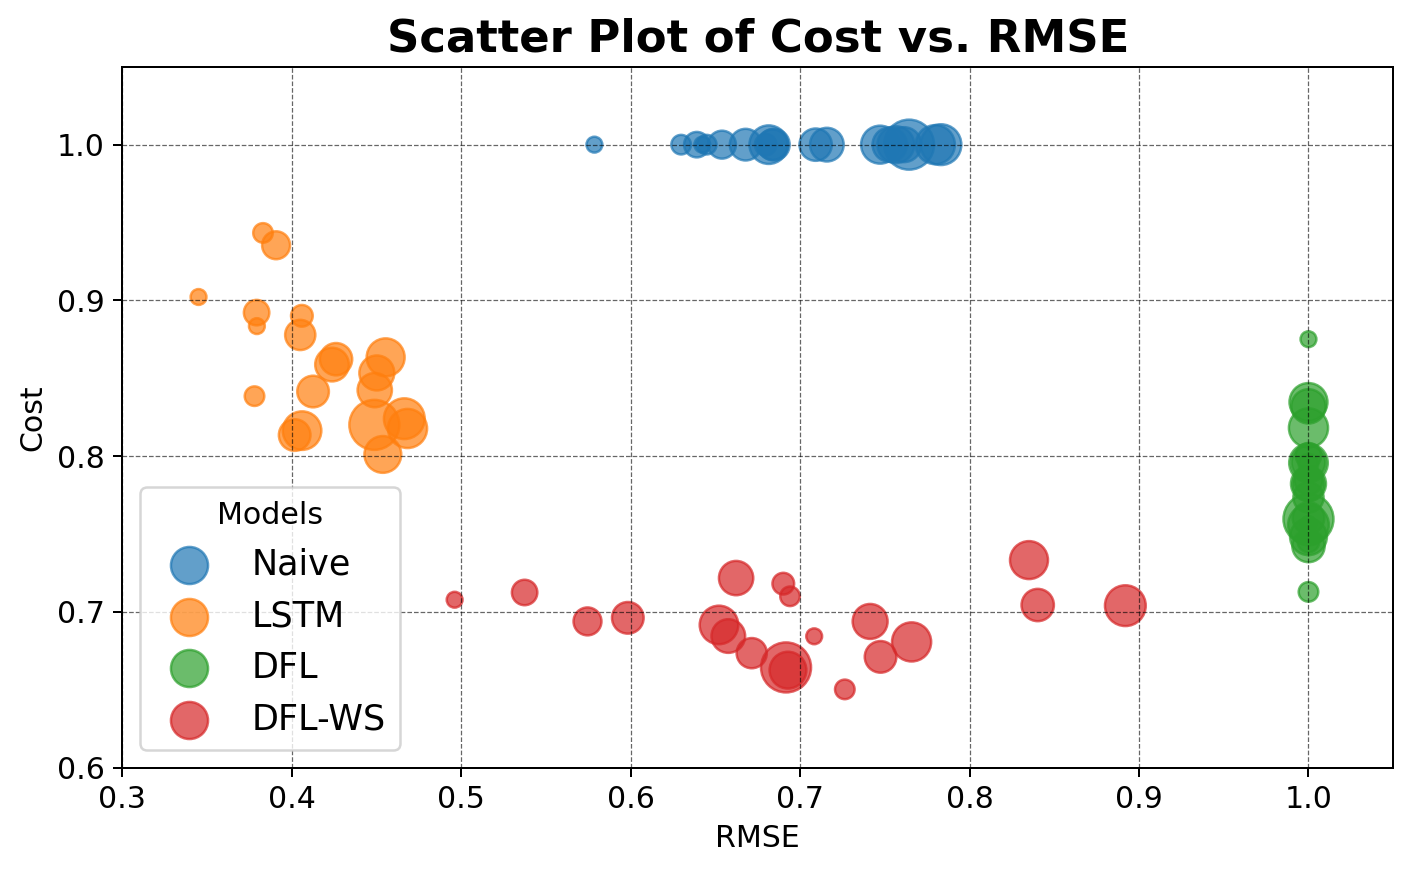

In [24]:
# Call the function to plot the scatter plot
plot_scatter_plot(rmse_df_norm[rmse_df_norm.columns[:-1]], cost_df_norm[cost_df_norm.columns[:-1]], df_long)

In [25]:
var = 'pv'
time = 'hour'

In [26]:
df_winter = df[df.index.month.isin([11, 12, 1, 2])]
df_spring = df[df.index.month.isin([3, 4, 9, 10])]
df_summer = df[df.index.month.isin([5, 6, 7, 8])]

In [27]:
df_lstm_winter = variable_df(df_winter, var,'lstm', time)
df_lstm_cvx_winter = variable_df(df_winter, var,'lstm_cvx', time)
df_cvx_winter = variable_df(df_winter, var,'cvx', time)
df_perfect_winter = variable_df(df_winter, var,'perfect', time)

df_lstm_spring = variable_df(df_spring, var,'lstm', time)
df_lstm_cvx_spring = variable_df(df_spring, var,'lstm_cvx', time)
df_cvx_spring = variable_df(df_spring, var,'cvx', time)
df_perfect_spring = variable_df(df_spring, var,'perfect', time)

df_lstm_summer = variable_df(df_summer, var,'lstm', time)
df_lstm_cvx_summer = variable_df(df_summer, var,'lstm_cvx', time)
df_cvx_summer = variable_df(df_summer, var,'cvx', time)
df_perfect_summer = variable_df(df_summer, var,'perfect', time)

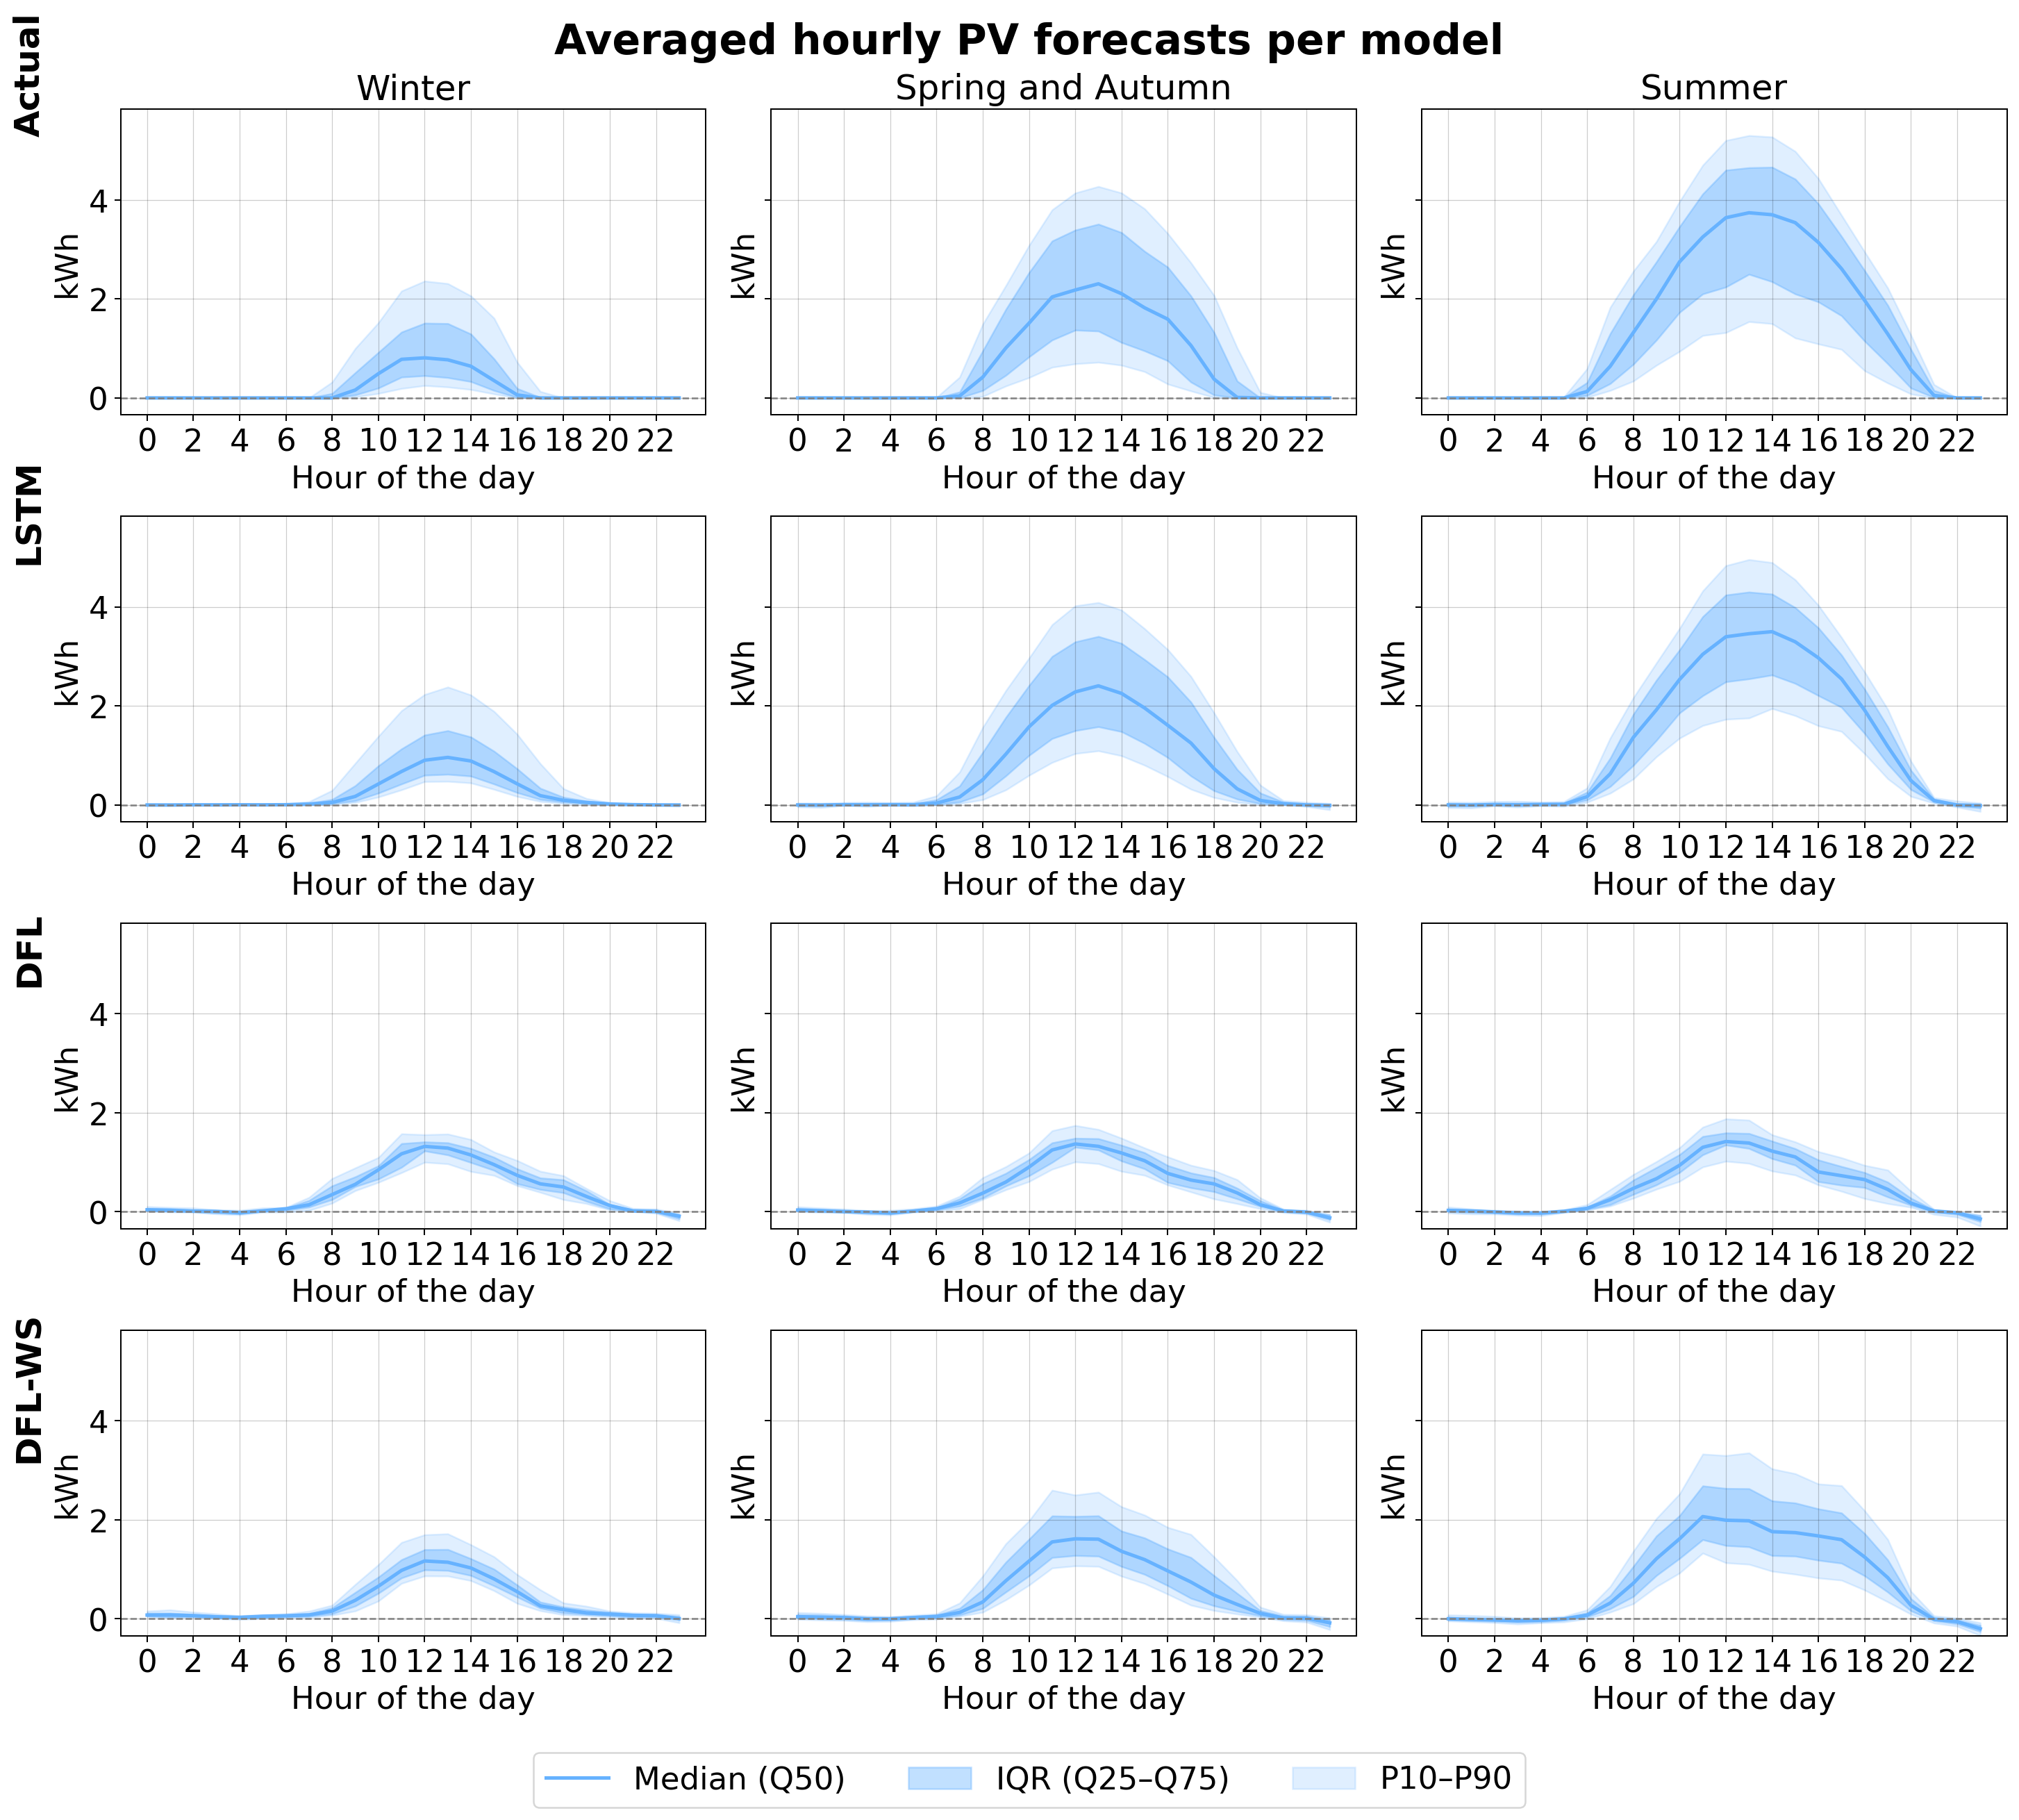

In [55]:
DEFAULT_FONTS = {
    "title": 24,
    "subtitle": 20,      # subplot titles like "Winter"
    "xlabel": 18,
    "ylabel": 18,
    "xticks": 18,
    "yticks": 18,
    "legend": 18
}

compare_hourly_quantile_plots([df_perfect_winter,df_perfect_spring,df_perfect_summer, df_lstm_winter, df_lstm_spring, df_lstm_summer, df_cvx_winter, df_cvx_spring, df_cvx_summer, df_lstm_cvx_winter, df_lstm_cvx_spring, df_lstm_cvx_summer], ['Actual', 'LSTM', 'DFL', 'DFL-WS'], columns=3, rows=4, titles=['Winter', 'Spring and Autumn', 'Summer', '', '', '', '','', '', '', '', ''], size=(16,14), x_axis='Hour of the day', fonts=DEFAULT_FONTS)

In [29]:
time = 'hour'

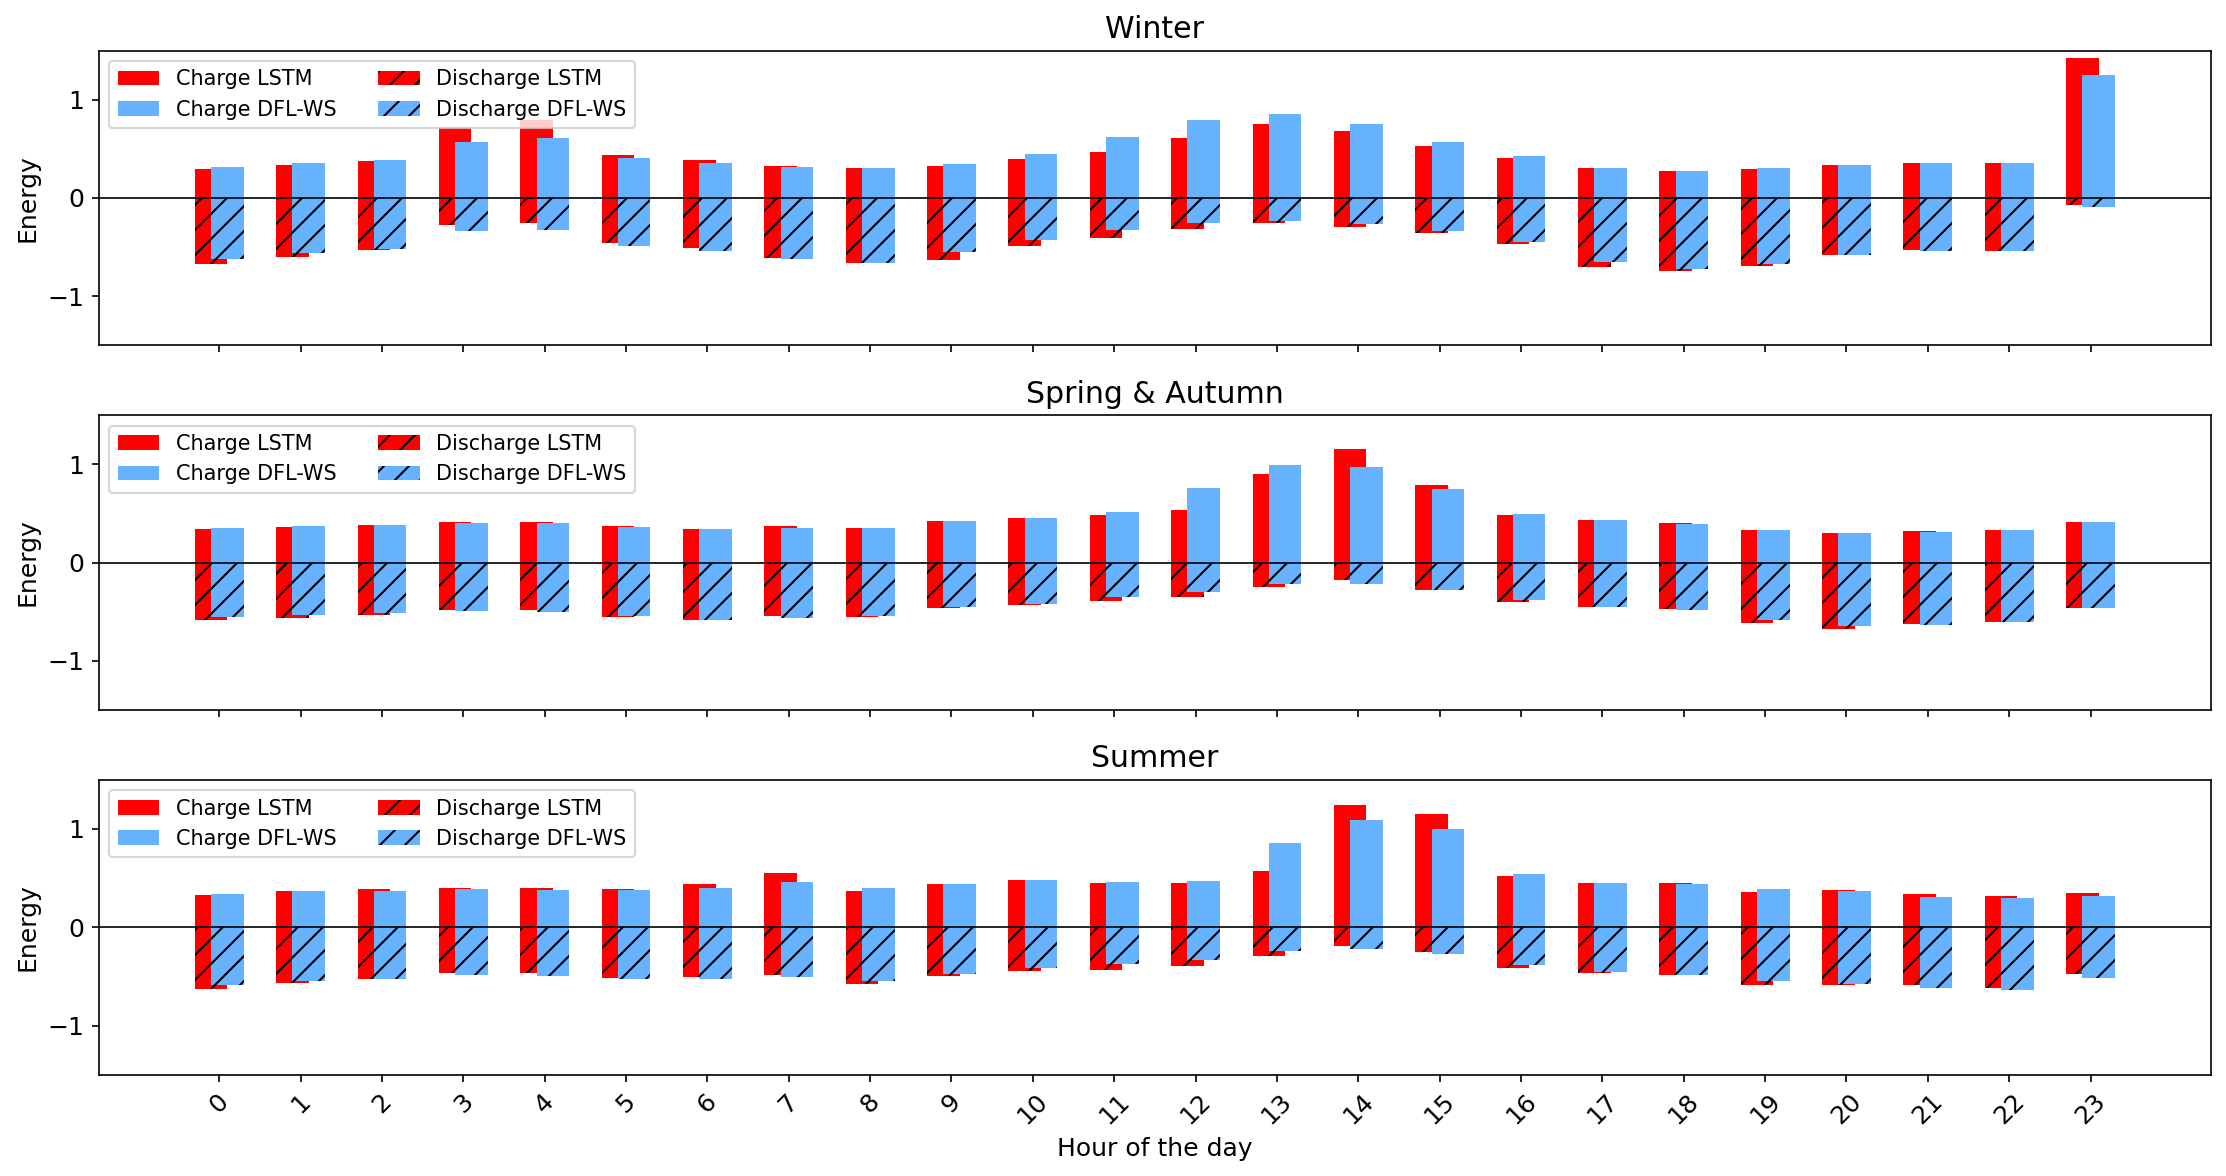

In [30]:
var = 'charge'
charge_lstm_winter = variable_df(df_winter, var,'lstm', time, quantiles=[0.5])
charge_lstm_spring = variable_df(df_spring, var,'lstm', time, quantiles=[0.5])
charge_lstm_summer = variable_df(df_summer, var,'lstm', time, quantiles=[0.5])
charge_lstm_cvx_winter = variable_df(df_winter, var,'lstm_cvx', time, quantiles=[0.5])
charge_lstm_cvx_spring = variable_df(df_spring, var,'lstm_cvx', time, quantiles=[0.5])
charge_lstm_cvx_summer = variable_df(df_summer, var,'lstm_cvx', time, quantiles=[0.5])
charge_perfect_winter = variable_df(df_winter, var,'perfect', time, quantiles=[0.5])
charge_perfect_spring = variable_df(df_spring, var,'perfect', time, quantiles=[0.5])
charge_perfect_summer = variable_df(df_summer, var,'perfect', time, quantiles=[0.5])

var = 'discharge'
discharge_lstm_winter = variable_df(df_winter, var,'lstm', time, quantiles=[0.5])
discharge_lstm_spring = variable_df(df_spring, var,'lstm', time, quantiles=[0.5])
discharge_lstm_summer = variable_df(df, var,'lstm', time, quantiles=[0.5])
discharge_lstm_cvx_winter = variable_df(df_winter, var,'lstm_cvx', time, quantiles=[0.5])
discharge_lstm_cvx_spring = variable_df(df_spring, var,'lstm_cvx', time, quantiles=[0.5])
discharge_lstm_cvx_summer = variable_df(df, var,'lstm_cvx', time, quantiles=[0.5])
discharge_perfect_winter = variable_df(df_winter, var,'perfect', time, quantiles=[0.5])
discharge_perfect_spring = variable_df(df_spring, var,'perfect', time, quantiles=[0.5])
discharge_perfect_summer = variable_df(df_summer, var,'perfect', time, quantiles=[0.5])
# Prepare x-axis
common_index = charge_lstm_winter.index
x = np.arange(len(common_index))
width = 0.4  # width of each bar
overlap = 0.2  # amount of overlap between bars

fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, figsize=(15, 8), sharex=True)

# === TOP: LSTM vs. LSTM-CVX ===
# Charge
ax1.bar(x - (width - overlap)/2, charge_lstm_winter['Q50'], width, label='Charge LSTM', color='r')
ax1.bar(x + (width - overlap)/2, charge_lstm_cvx_winter['Q50'], width, label='Charge DFL-WS', color='#66B2FF')
# Discharge (as negative)
ax1.bar(x - (width - overlap)/2, -discharge_lstm_winter['Q50'], width, label='Discharge LSTM', color='r', hatch='//')
ax1.bar(x + (width - overlap)/2, -discharge_lstm_cvx_winter['Q50'], width, label='Discharge DFL-WS', color='#66B2FF', hatch='//')

ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_ylim(-1.5,1.5)
ax1.set_ylabel('Energy')
ax1.set_title('Winter')
ax1.legend(loc='upper left', fontsize=10, ncol=2)

# === MIDDLE: CVX vs. Perfect ===
# Charge
ax2.bar(x - (width - overlap)/2, charge_lstm_spring['Q50'], width, label='Charge LSTM', color='r')
ax2.bar(x + (width - overlap)/2, charge_lstm_cvx_spring['Q50'], width, label='Charge DFL-WS', color='#66B2FF')
# Discharge (as negative)
ax2.bar(x - (width - overlap)/2, -discharge_lstm_spring['Q50'], width, label='Discharge LSTM', color='r', hatch='//')
ax2.bar(x + (width - overlap)/2, -discharge_lstm_cvx_spring['Q50'], width, label='Discharge DFL-WS', color='#66B2FF', hatch='//')

ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylim(-1.5,1.5)
ax2.set_ylabel('Energy')
ax2.set_title('Spring & Autumn')
ax2.legend(loc='upper left', fontsize=10, ncol=2)

# === BOTTOM: CVX vs. Perfect ===
# Charge
ax3.bar(x - (width - overlap)/2, charge_lstm_summer['Q50'], width, label='Charge LSTM', color='r')
ax3.bar(x + (width - overlap)/2, charge_lstm_cvx_summer['Q50'], width, label='Charge DFL-WS', color='#66B2FF')
# Discharge (as negative)
ax3.bar(x - (width - overlap)/2, -discharge_lstm_summer['Q50'], width, label='Discharge LSTM', color='r', hatch='//')
ax3.bar(x + (width - overlap)/2, -discharge_lstm_cvx_summer['Q50'], width, label='Discharge DFL-WS', color='#66B2FF', hatch='//')

ax3.axhline(0, color='black', linewidth=0.8)
ax3.set_ylim(-1.5,1.5)
ax3.set_ylabel('Energy')
ax3.set_title('Summer')
ax3.set_xlabel('Hour of the day')
ax3.set_xticks(x)
ax3.set_xticklabels(common_index, rotation=45)
ax3.legend(loc='upper left', fontsize=10, ncol=2)

plt.tight_layout()
plt.show()

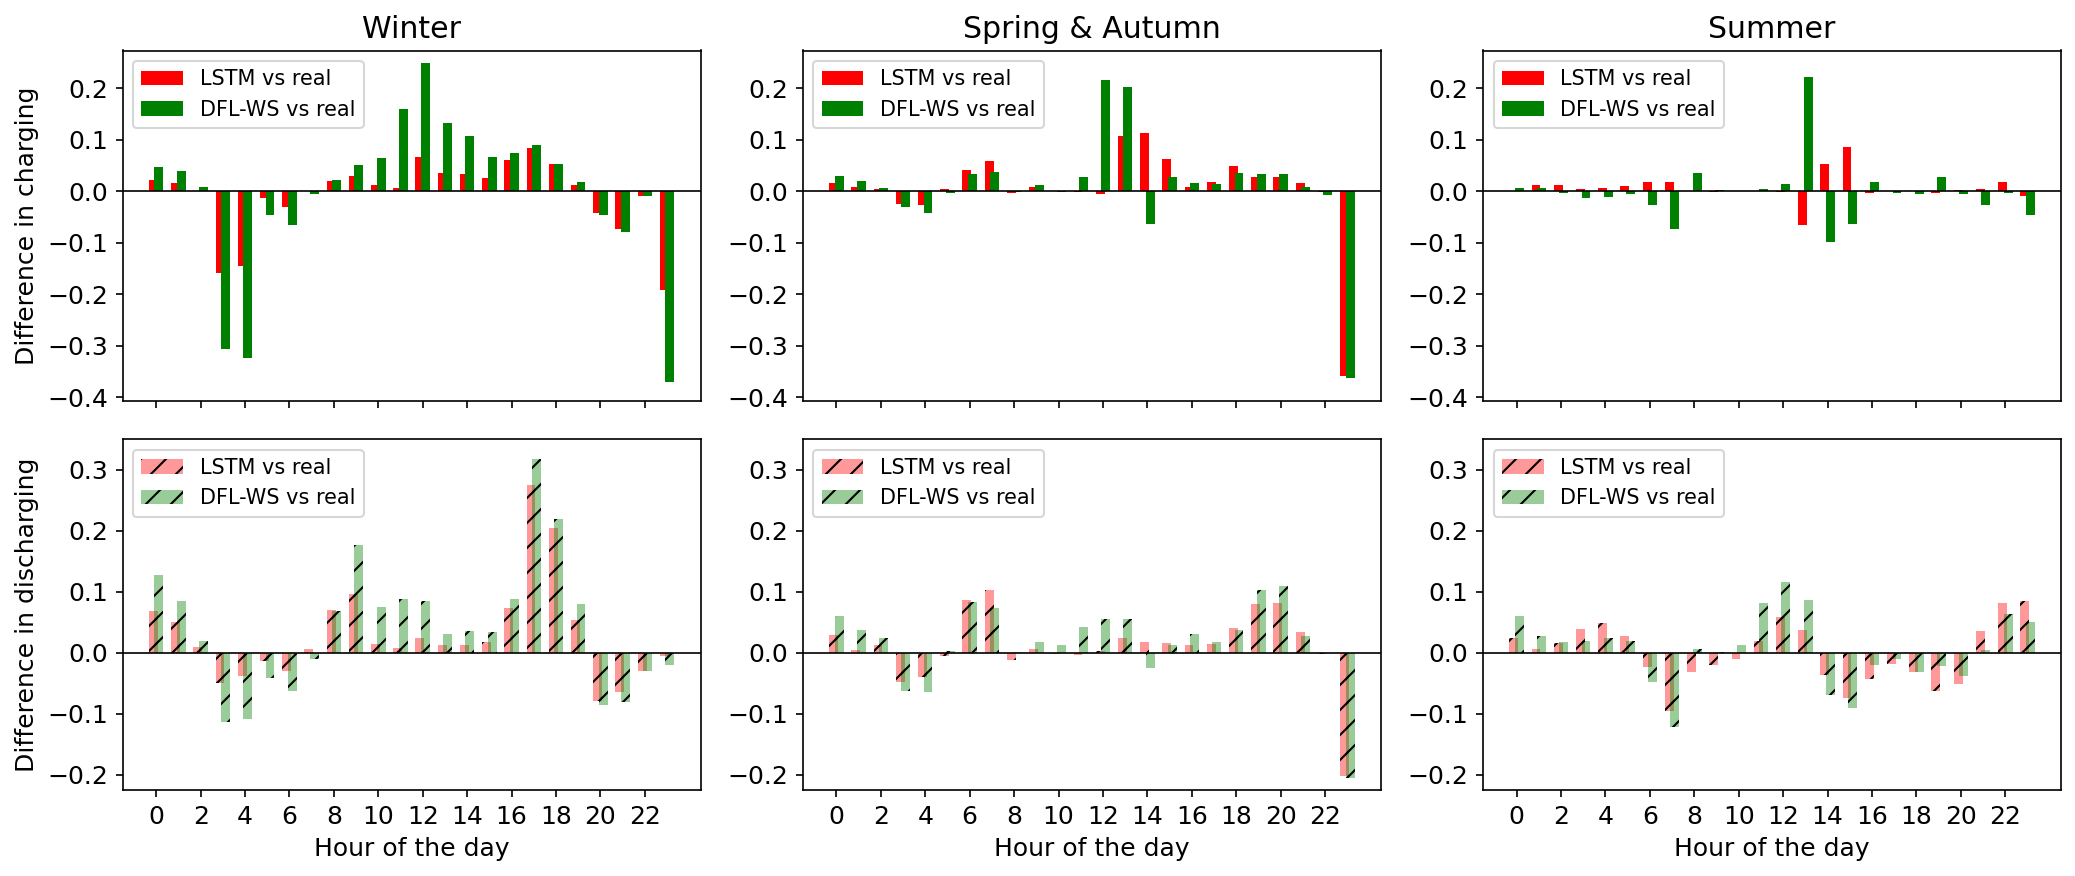

In [31]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 6), sharex=True)
axes = axes.flatten()  # Flatten to make indexing easy
width = 0.4  # width of each bar
overlap = 0.15  # amount of overlap between bars
# Axes assignment
ax1, ax2, ax3, ax4, ax5, ax6 = axes
common_index = charge_lstm_winter.index
x = np.arange(len(common_index))
# === TOP: LSTM vs. LSTM-CVX ===
# Charge
ax1.bar(x - (width - overlap)/2, charge_lstm_winter['Q50'] - charge_perfect_winter['Q50'], width, label='LSTM vs real', color='r')
ax1.bar(x + (width - overlap)/2, charge_lstm_cvx_winter['Q50'] - charge_perfect_winter['Q50'], width, label='DFL-WS vs real', color='g')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_xticks(range(0, len(common_index), 2))
ax1.set_ylabel('Difference in charging')
ax1.set_title('Winter')
ax1.legend(loc='upper left', fontsize=10)

# Discharge
ax4.bar(x - (width - overlap)/2, -discharge_lstm_winter['Q50'] - (-discharge_perfect_winter['Q50']), width, label='LSTM vs real', color='r', alpha=0.4, hatch='//')
ax4.bar(x + (width - overlap)/2, -discharge_lstm_cvx_winter['Q50'] - (-discharge_perfect_winter['Q50']), width, label='DFL-WS vs real', color='g', alpha=0.4, hatch='//')
ax4.axhline(0, color='black', linewidth=0.8)
ax4.set_ylabel('Difference in discharging')
ax4.set_xticks(range(0, len(common_index), 2))
ax4.set_xlabel('Hour of the day')
ax4.legend(loc='upper left', fontsize=10)

# === MIDDLE: Spring & Autumn ===
# Charge
ax2.bar(x - (width - overlap)/2, charge_lstm_spring['Q50'] - charge_perfect_spring['Q50'], width, label='LSTM vs real', color='r')
ax2.bar(x + (width - overlap)/2, charge_lstm_cvx_spring['Q50'] - charge_perfect_spring['Q50'], width, label='DFL-WS vs real', color='g')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticks(range(0, len(common_index), 2))
ax2.set_title('Spring & Autumn')
ax2.legend(loc='upper left', fontsize=10)

# Discharge
ax5.bar(x - (width - overlap)/2, -discharge_lstm_spring['Q50'] - (-discharge_perfect_spring['Q50']), width, label='LSTM vs real', color='r', alpha=0.4, hatch='//')
ax5.bar(x + (width - overlap)/2, -discharge_lstm_cvx_spring['Q50'] - (-discharge_perfect_spring['Q50']), width, label='DFL-WS vs real', color='g', alpha=0.4, hatch='//')
ax5.axhline(0, color='black', linewidth=0.8)
ax5.set_xlabel('Hour of the day')
ax5.set_xticks(range(0, len(common_index), 2))
ax5.legend(loc='upper left', fontsize=10)

# === BOTTOM: Summer ===
# Charge
ax3.bar(x - (width - overlap)/2, charge_lstm_summer['Q50'] - charge_perfect_summer['Q50'], width, label='LSTM vs real', color='r')
ax3.bar(x + (width - overlap)/2, charge_lstm_cvx_summer['Q50'] - charge_perfect_summer['Q50'], width, label='DFL-WS vs real', color='g')
ax3.axhline(0, color='black', linewidth=0.8)
ax3.set_xticks(range(0, len(common_index), 2))
ax3.set_title('Summer')
ax3.legend(loc='upper left', fontsize=10)

# Discharge
ax6.bar(x - (width - overlap)/2, -discharge_lstm_summer['Q50'] - (-discharge_perfect_summer['Q50']), width, label='LSTM vs real', color='r', alpha=0.4, hatch='//')
ax6.bar(x + (width - overlap)/2, -discharge_lstm_cvx_summer['Q50'] - (-discharge_perfect_summer['Q50']), width, label='DFL-WS vs real', color='g', alpha=0.4, hatch='//')
ax6.axhline(0, color='black', linewidth=0.8)
ax6.set_xlabel('Hour of the day')
ax6.set_xticks(range(0, len(common_index), 2))
ax6.legend(loc='upper left', fontsize=10)
# Set consistent y-axis limits for charge plots (ax1, ax2, ax3)
charge_axes = [ax1, ax2, ax3]
charge_ys = []

for ax in charge_axes:
    for bar in ax.patches:
        charge_ys.append(bar.get_height())

charge_ymin = min(charge_ys)
charge_ymax = max(charge_ys)

for ax in charge_axes:
    ax.set_ylim(charge_ymin*1.1, charge_ymax*1.1)

# Set consistent y-axis limits for discharge plots (ax4, ax5, ax6)
discharge_axes = [ax4, ax5, ax6]
discharge_ys = []

for ax in discharge_axes:
    for bar in ax.patches:
        discharge_ys.append(bar.get_height())

discharge_ymin = min(discharge_ys)
discharge_ymax = max(discharge_ys)

for ax in discharge_axes:
    ax.set_ylim(discharge_ymin*1.1, discharge_ymax*1.1)
plt.tight_layout()
plt.show()


In [32]:
df_winter_perfect = df[df.index.month.isin([11, 12, 1, 2])].xs('cost', level='variable', axis=1).xs('perfect', level='dictionary', axis=1)
df_spring_perfect = df[df.index.month.isin([3, 4, 9, 10])].xs('cost', level='variable', axis=1).xs('perfect', level='dictionary', axis=1)
df_summer_perfect = df[df.index.month.isin([5, 6, 7, 8])].xs('cost', level='variable', axis=1).xs('perfect', level='dictionary', axis=1)

df_winter_lstm = df[df.index.month.isin([11, 12, 1, 2])].xs('cost', level='variable', axis=1).xs('lstm', level='dictionary', axis=1)
df_spring_lstm = df[df.index.month.isin([3, 4, 9, 10])].xs('cost', level='variable', axis=1).xs('lstm', level='dictionary', axis=1)
df_summer_lstm = df[df.index.month.isin([5, 6, 7, 8])].xs('cost', level='variable', axis=1).xs('lstm', level='dictionary', axis=1)

df_winter_lstmcvx = df[df.index.month.isin([11, 12, 1, 2])].xs('cost', level='variable', axis=1).xs('lstm_cvx', level='dictionary', axis=1)
df_spring_lstmcvx = df[df.index.month.isin([3, 4, 9, 10])].xs('cost', level='variable', axis=1).xs('lstm_cvx', level='dictionary', axis=1)
df_summer_lstmcvx = df[df.index.month.isin([5, 6, 7, 8])].xs('cost', level='variable', axis=1).xs('lstm_cvx', level='dictionary', axis=1)

In [33]:
cost_array = np.array([[sum(sum(df_winter_perfect.values)), sum(sum(df_winter_lstm.values)), sum(sum(df_winter_lstmcvx.values))],
                        [sum(sum(df_spring_perfect.values)), sum(sum(df_spring_lstm.values)), sum(sum(df_spring_lstmcvx.values))],
                        [sum(sum(df_summer_perfect.values)), sum(sum(df_summer_lstm.values)), sum(sum(df_summer_lstmcvx.values))]])

In [34]:
cost_array_scaled = (cost_array / cost_array[:, [0]])

In [35]:
cost_array_scaled - cost_array_scaled[:, [-1]]

array([[-0.06479604,  0.00813237,  0.        ],
       [-0.34174954,  0.05359571,  0.        ],
       [ 0.30555555, -0.11061069,  0.        ]])